In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report
)

from sklearn.preprocessing import StandardScaler

from sklearn.utils import resample

In [2]:
df = pd.read_json(
    "../data/processed/logistic_data.json"
)

df.head()

,avg_male_weight,avg_female_weight,hypoallergenic,is_large
0,4.0,4.0,1,0
1,25.0,22.5,0,1
2,21.5,19.0,0,0
3,47.5,42.5,0,1
4,6.5,6.5,0,0


In [3]:
print(df.columns)

Index(['avg_male_weight', 'avg_female_weight', 'hypoallergenic', 'is_large'], dtype='object')


In [4]:
df['is_large'].value_counts()

is_large
0    158
1    125
Name: count, dtype: int64

In [5]:
mayoria = df[df.is_large == 1]

minoria = df[df.is_large == 0]

minoria_oversample = resample(

    minoria,

    replace=True,

    n_samples=len(mayoria),

    random_state=42
)

df_balanceado = pd.concat([
    mayoria,
    minoria_oversample
])

df_balanceado['is_large'].value_counts()

is_large
1    125
0    125
Name: count, dtype: int64

In [6]:
y = df_balanceado['is_large']

X = df_balanceado[[

    'avg_male_weight',

    'avg_female_weight',

    'hypoallergenic'
]]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
modelo = LogisticRegression(

    random_state=42
)

modelo.fit(

    X_train,

    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [10]:
y_pred = modelo.predict(X_test)

y_prob = modelo.predict_proba(X_test)[:, 1]

In [11]:
accuracy = accuracy_score(

    y_test,

    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9600


In [12]:
fpr, tpr, thresholds = roc_curve(

    y_test,

    y_prob
)

roc_auc = auc(

    fpr,

    tpr
)

print(f"AUC: {roc_auc:.4f}")

AUC: 1.0000


In [13]:
precision = precision_score(

    y_test,

    y_pred
)

print(f"Precision: {precision:.4f}")

Precision: 0.9259


In [14]:
recall = recall_score(

    y_test,

    y_pred
)

print(f"Recall: {recall:.4f}")

Recall: 1.0000


In [15]:
f1 = f1_score(

    y_test,

    y_pred
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9615


In [16]:
cm = confusion_matrix(

    y_test,

    y_pred
)

print(cm)

[[23  2]
 [ 0 25]]


In [17]:
print(

    classification_report(

        y_test,

        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        25
           1       0.93      1.00      0.96        25

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



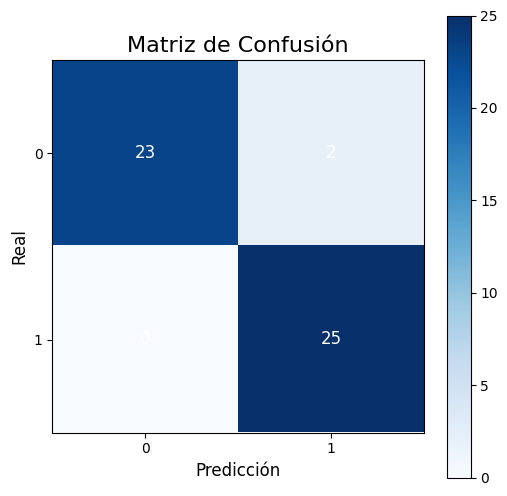

In [18]:
plt.figure(figsize=(6,6))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title(
    "Matriz de Confusión",
    fontsize=16
)

plt.colorbar()

plt.xlabel(
    "Predicción",
    fontsize=12
)

plt.ylabel(
    "Real",
    fontsize=12
)

# Etiquetas ejes

classes = [0, 1]

plt.xticks(
    np.arange(len(classes)),
    classes
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

# Números dentro de las celdas

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(

            j,
            i,

            cm[i, j],

            ha="center",

            va="center",

            color="white",

            fontsize=12
        )

plt.show()

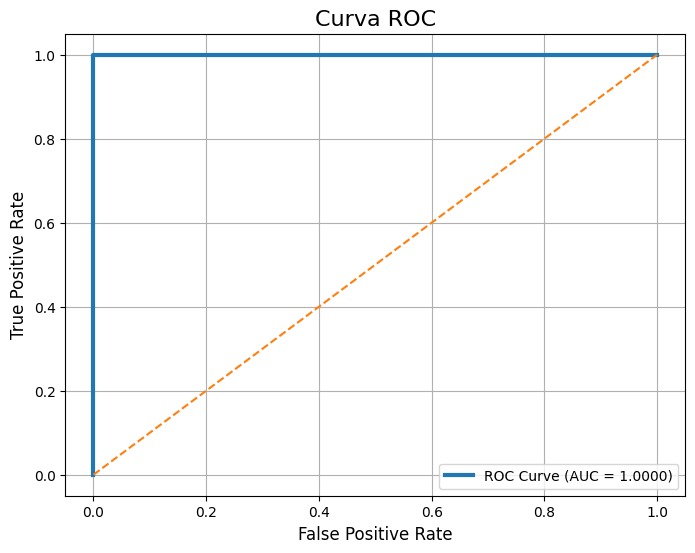

In [19]:
plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    linewidth=3,

    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

# Línea diagonal

plt.plot(

    [0,1],

    [0,1],

    linestyle='--'
)

plt.xlabel(

    'False Positive Rate',

    fontsize=12
)

plt.ylabel(

    'True Positive Rate',

    fontsize=12
)

plt.title(

    'Curva ROC',

    fontsize=16
)

plt.legend()

plt.grid()

plt.show()